# RPL Dashboard - Data Loading & Dual DataFrame Analysis (KH & EN)

**Dataset:** `RPL_Dashboard_V.1.csv`  
**Output Notebooks:** `assessment.ipynb` & `assestment.ipynb`

### Objectives & Architecture:
1. **Data Loading & Cleaning:** Load raw RPL dataset and drop unwanted attributes.
   - **Explicit Column Drops:** Drop `Serial_Code`, `Path`, `Pics`, `CardNo`.
   - **CM Column Drops:** Drop all Committee Meeting (`CM`) fields (`Date_Committee_Meeting`, `CM_Day_KH`, `CM_Month_KH`, `CM_Year_KH`).
   - **DI & DE Column Drops:** Drop all Date of Issue (`DI`) and Date of Expiry (`DE`) fields (`Date_Issue_EN`, `DI_Day_KH`, `DI_Month_KH`, `DI_Year_KH`, `Date_Expiry_EN`, `DE_Day_KH`, `DE_Month_KH`, `DE Year (KH)`).

2. **Dual DataFrame Structure:**
   - **`df_kh` (Khmer DataFrame)**: Keeps Khmer (`KH`) attributes (`Occupation_KH`, `NQ_KH`, `AT_KH`, `Gender_KH`) and drops `EN` attributes. Used for internal data exploration and KH crosstabs.
   - **`df_en` (English DataFrame)**: Drops Khmer attributes (`Occupation_KH`, `NQ_KH`, `AT_KH`, `Gender_KH`) and keeps `EN` attributes (`Occupation_EN`, `NQ_EN`, `AT_EN`, `Gender_EN`). Used for data visualization charts and English tables.

3. **Key Insights & Visualizations:**
   - Overall Gender Total (Male vs Female vs Total count & percentage). Pie chart uses black text color for percentage values.
   - Occupation, Assessment Center (AT), National Qualification (NQ), and Sponsor breakdowns by Gender.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Configure pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Set plotting style
plt.style.use('ggplot')

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 1. Raw Data Loading
Load the raw dataset `RPL_Dashboard_V.1.csv` into a Pandas DataFrame.


In [2]:
# Load raw dataset
df_raw = pd.read_csv('RPL_Dashboard_V.1.csv')

print(f"Raw Dataset Shape: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
print("\nRaw Columns:")
for i, col in enumerate(df_raw.columns, 1):
    print(f"{i:2d}. {col}")


Raw Dataset Shape: 1405 rows, 33 columns

Raw Columns:
 1. No
 2. Serial_Code
 3. Number
 4. FullName
 5. Latin
 6. Gender_KH
 7. Gender_EN
 8. DOB
 9. DOB_Day_KH
10. DOB_Month_KH
11. DOB_Year_KH
12. Occupation_KH
13. Occupation_EN
14. NQ_KH
15. NQ_EN
16. AT_KH
17. AT_EN
18. Path
19. Pics
20. CardNo
21. Date_Committee_Meeting
22. CM_Day_KH
23. CM_Month_KH
24. CM_Year_KH
25. Date_Issue_EN
26. DI_Day_KH
27. DI_Month_KH
28. DI_Year_KH
29. Date_Expiry_EN
30. DE_Day_KH
31. DE_Month_KH
32. DE Year (KH)
33. Sponsors


## 2. Separate into 2 DataFrames: `df_kh` and `df_en`
1. Apply common column drop rules (`Serial_Code`, `Path`, `Pics`, `CardNo`, `CM_*`, `DI_*`, `DE_*`).
2. Create **`df_kh`** by dropping all English `_EN` columns (for internal KH analysis).
3. Create **`df_en`** by dropping Khmer target columns `Occupation_KH`, `NQ_KH`, `AT_KH`, `Gender_KH` (for visualization).


In [3]:
# Common column drops
explicit_drops = ['Serial_Code', 'Path', 'Pics', 'CardNo']
cm_cols = [c for c in df_raw.columns if c.startswith('CM') or 'Committee_Meeting' in c]
di_cols = [c for c in df_raw.columns if c.startswith('DI') or 'Date_Issue' in c]
de_cols = [c for c in df_raw.columns if c.startswith('DE') or 'Date_Expiry' in c]

common_drops = list(set(explicit_drops + cm_cols + di_cols + de_cols))

# 1. Create df_kh (Khmer DataFrame - drop EN columns)
en_cols = [c for c in df_raw.columns if c.endswith('_EN')]
df_kh = df_raw.drop(columns=[c for c in (common_drops + en_cols) if c in df_raw.columns]).copy()

# 2. Create df_en (English DataFrame - drop target KH columns)
kh_target_cols = ['Gender_KH', 'Occupation_KH', 'NQ_KH', 'AT_KH']
df_en = df_raw.drop(columns=[c for c in (common_drops + kh_target_cols) if c in df_raw.columns]).copy()

print(f"df_kh Shape: {df_kh.shape[0]} rows, {df_kh.shape[1]} columns")
print(f"df_kh Columns: {df_kh.columns.tolist()}")

print(f"\ndf_en Shape: {df_en.shape[0]} rows, {df_en.shape[1]} columns")
print(f"df_en Columns: {df_en.columns.tolist()}")


df_kh Shape: 1405 rows, 13 columns
df_kh Columns: ['No', 'Number', 'FullName', 'Latin', 'Gender_KH', 'DOB', 'DOB_Day_KH', 'DOB_Month_KH', 'DOB_Year_KH', 'Occupation_KH', 'NQ_KH', 'AT_KH', 'Sponsors']

df_en Shape: 1405 rows, 13 columns
df_en Columns: ['No', 'Number', 'FullName', 'Latin', 'Gender_EN', 'DOB', 'DOB_Day_KH', 'DOB_Month_KH', 'DOB_Year_KH', 'Occupation_EN', 'NQ_EN', 'AT_EN', 'Sponsors']


## 3. Internal Data Exploration & Crosstabs (`df_kh`)
Exploring candidate data internally using Khmer attributes (`df_kh`).


In [4]:
# Display first 5 rows of df_kh
df_kh.head()


,No,Number,FullName,Latin,Gender_KH,DOB,DOB_Day_KH,DOB_Month_KH,DOB_Year_KH,Occupation_KH,NQ_KH,AT_KH,Sponsors
0,1,1,វ៉ាន បញ្ញា,VAN PANHA,ប្រុស,1-Apr-01,១,មេសា,២០០១,ការផ្សាអគ្គិសនី,វិញ្ញាបនបត្រវិជ្ជាជីវៈ,វិទ្យាស្ថានបច្ចេកទេសឧស្សាហកម្ម,PB-2020
1,1,2,ប៉ិច សំអុន,PICH SAMON,ប្រុស,11-Sep-79,១១,កញ្ញា,១៩៧៩,ការផ្សាអគ្គិសនី,វិញ្ញាបនបត្រវិជ្ជាជីវៈ,វិទ្យាស្ថានបច្ចេកទេសឧស្សាហកម្ម,PB-2020
2,1,3,ស៊ុយ ច័ន្ទ,SUY CHANN,ប្រុស,3-Jun-81,៣,មិថុនា,១៩៨១,ការផ្សាអគ្គិសនី,វិញ្ញាបនបត្រវិជ្ជាជីវៈ,វិទ្យាស្ថានបច្ចេកទេសឧស្សាហកម្ម,PB-2020
3,2,4,គឹម ឡាយ,KIM LAY,ប្រុស,3-Jun-81,៣,មិថុនា,១៩៨១,ការផ្សាអគ្គិសនី,វិញ្ញាបនបត្រវិជ្ជាជីវៈ,វិទ្យាស្ថានបច្ចេកទេសឧស្សាហកម្ម,PB-2020
4,2,5,សាលី សាវ៉ាត,SALY SAVATH,ប្រុស,12-Mar-86,១២,មីនា,១៩៨៦,ការផ្សាអគ្គិសនី,វិញ្ញាបនបត្រវិជ្ជាជីវៈ,វិទ្យាស្ថានបច្ចេកទេសឧស្សាហកម្ម,PB-2020


In [5]:
print("=== 1. Overall Gender Total (KH) ===")
gender_kh_df = pd.crosstab(df_kh['Gender_KH'], columns='Count')
gender_kh_df['Percentage (%)'] = (gender_kh_df['Count'] / len(df_kh) * 100).round(2)
gender_kh_df.loc['Total'] = [len(df_kh), 100.0]
display(gender_kh_df)

print("\n=== 2. Occupation Breakdown per Gender (KH) ===")
occ_kh_ct = pd.crosstab(df_kh['Occupation_KH'], df_kh['Gender_KH'], margins=True, margins_name='Total')
display(occ_kh_ct.sort_values(by='Total', ascending=False))

print("\n=== 3. Assessment Center Breakdown per Gender (KH) ===")
at_kh_ct = pd.crosstab(df_kh['AT_KH'], df_kh['Gender_KH'], margins=True, margins_name='Total')
display(at_kh_ct.sort_values(by='Total', ascending=False))

print("\n=== 4. National Qualification Breakdown per Gender (KH) ===")
nq_kh_ct = pd.crosstab(df_kh['NQ_KH'], df_kh['Gender_KH'], margins=True, margins_name='Total')
display(nq_kh_ct.sort_values(by='Total', ascending=False))

print("\n=== 5. Sponsor Breakdown per Gender (KH) ===")
sp_kh_ct = pd.crosstab(df_kh['Sponsors'], df_kh['Gender_KH'], margins=True, margins_name='Total')
display(sp_kh_ct.sort_values(by='Total', ascending=False))


=== 1. Overall Gender Total (KH) ===


col_0,Count,Percentage (%)
Gender_KH,,
ប្រុស,1200.0,85.41
ស្រី,205.0,14.59
Total,1405.0,100.00



=== 2. Occupation Breakdown per Gender (KH) ===


Gender_KH,ប្រុស,ស្រី,Total
Occupation_KH,,,
Total,1200,205,1405
ការដំឡើងបណ្តាញអគ្គិសនីក្នុងអគារ,456,96,552
ការងារកំបោរ,322,4,326
រចនាក្រាហ្វិកដោយកុំព្យូទ័រ,80,55,135
សេវាកម្មកុំព្យូទ័រ,69,21,90
ការងារដំឡើងពុម្ព,79,2,81
ការផ្សាអគ្គិសនី,51,0,51
ការកែច្នៃបន្លែ និងផ្លែឈើ,21,19,40
ការបន្ស៊ីលោហៈ,39,0,39



=== 3. Assessment Center Breakdown per Gender (KH) ===


Gender_KH,ប្រុស,ស្រី,Total
AT_KH,,,
Total,1200,205,1405
មជ្ឈមណ្ឌលវាយតម្លៃសមត្ថភាពព្រះកុសុមៈ,420,89,509
មជ្ឈមណ្ឌលវាយតម្លៃសមត្ថភាពបាត់ដំបង,230,39,269
មជ្ឈមណ្ឌលវាយតម្លៃសមត្ថភាពអង្គរ,194,17,211
មជ្ឈមណ្ឌលវាយតម្លៃសមត្ថភាពខេត្តក្រចេះ,144,8,152
មជ្ឈមណ្ឌលវាយតម្លៃសមត្ថភាពខេត្តតាកែវ,123,27,150
វិទ្យាស្ថានជាតិពហុបច្ចេកទេសកម្ពុជា,46,14,60
វិទ្យាស្ថានបច្ចេកទេសឧស្សាហកម្ម,40,0,40
វិទ្យាស្ថានជាតិវីជ្ជាជីវៈបាត់ដំបង,3,11,14



=== 4. National Qualification Breakdown per Gender (KH) ===


Gender_KH,ប្រុស,ស្រី,Total
NQ_KH,,,
Total,1200,205,1405
វិញ្ញាបនបត្រវិជ្ជាជីវៈ,840,112,952
សញ្ញាបត្របច្ចេកទេសនិងវិជ្ជាជីវៈ ១,360,93,453



=== 5. Sponsor Breakdown per Gender (KH) ===


Gender_KH,ប្រុស,ស្រី,Total
Sponsors,,,
Total,1200,205,1405
PB-2020,487,49,536
TVETSDP,195,77,272
Other,182,37,219
PB-2022,89,11,100
PB-2021,92,8,100
ILO-2023,80,4,84
Swiss-Contact,47,8,55
PIN,28,11,39


## 4. Visualization Tables & Charts (`df_en`)
Using **`df_en`** (dropping KH target columns) to generate summary tables and clean matplotlib visual charts.


In [6]:
# Display first 5 rows of df_en
df_en.head()


,No,Number,FullName,Latin,Gender_EN,DOB,DOB_Day_KH,DOB_Month_KH,DOB_Year_KH,Occupation_EN,NQ_EN,AT_EN,Sponsors
0,1,1,វ៉ាន បញ្ញា,VAN PANHA,Male,1-Apr-01,១,មេសា,២០០១,Arc Welding,Vocational Certificate,Industrial Technology Institute,PB-2020
1,1,2,ប៉ិច សំអុន,PICH SAMON,Male,11-Sep-79,១១,កញ្ញា,១៩៧៩,Arc Welding,Vocational Certificate,Industrial Technology Institute,PB-2020
2,1,3,ស៊ុយ ច័ន្ទ,SUY CHANN,Male,3-Jun-81,៣,មិថុនា,១៩៨១,Arc Welding,Vocational Certificate,Industrial Technology Institute,PB-2020
3,2,4,គឹម ឡាយ,KIM LAY,Male,3-Jun-81,៣,មិថុនា,១៩៨១,Arc Welding,Vocational Certificate,Industrial Technology Institute,PB-2020
4,2,5,សាលី សាវ៉ាត,SALY SAVATH,Male,12-Mar-86,១២,មីនា,១៩៨៦,Arc Welding,Vocational Certificate,Industrial Technology Institute,PB-2020


In [7]:
print("=== 1. Overall Gender Total (EN) ===")
gender_en_df = pd.crosstab(df_en['Gender_EN'], columns='Candidate Count')
gender_en_df['Percentage (%)'] = (gender_en_df['Candidate Count'] / len(df_en) * 100).round(2)
gender_en_df.loc['Total'] = [len(df_en), 100.0]
display(gender_en_df)

print("\n=== 2. Occupation Breakdown per Gender (EN) ===")
occ_en_ct = pd.crosstab(df_en['Occupation_EN'], df_en['Gender_EN'], margins=True, margins_name='Total')
occ_en_ct = occ_en_ct[['Male', 'Female', 'Total']].sort_values(by='Total', ascending=False)
display(occ_en_ct)

print("\n=== 3. Assessment Center Breakdown per Gender (EN) ===")
at_en_ct = pd.crosstab(df_en['AT_EN'], df_en['Gender_EN'], margins=True, margins_name='Total')
at_en_ct = at_en_ct[['Male', 'Female', 'Total']].sort_values(by='Total', ascending=False)
display(at_en_ct)

print("\n=== 4. National Qualification Breakdown per Gender (EN) ===")
nq_en_ct = pd.crosstab(df_en['NQ_EN'], df_en['Gender_EN'], margins=True, margins_name='Total')
nq_en_ct = nq_en_ct[['Male', 'Female', 'Total']].sort_values(by='Total', ascending=False)
display(nq_en_ct)

print("\n=== 5. Sponsor Breakdown per Gender (EN) ===")
sp_en_ct = pd.crosstab(df_en['Sponsors'], df_en['Gender_EN'], margins=True, margins_name='Total')
sp_en_ct = sp_en_ct[['Male', 'Female', 'Total']].sort_values(by='Total', ascending=False)
display(sp_en_ct)


=== 1. Overall Gender Total (EN) ===


col_0,Candidate Count,Percentage (%)
Gender_EN,,
Female,204.0,14.52
Male,1201.0,85.48
Total,1405.0,100.00



=== 2. Occupation Breakdown per Gender (EN) ===


Gender_EN,Male,Female,Total
Occupation_EN,,,
Total,1201,204,1405
Building Electrical Wiring,456,96,552
Masonry,322,4,326
Graphic Design,80,55,135
Computer Servicing,69,21,90
Rough Carpentry,79,2,81
Arc Welding,51,0,51
Fruit and Vegetable Processing,21,19,40
Machining,39,0,39



=== 3. Assessment Center Breakdown per Gender (EN) ===


Gender_EN,Male,Female,Total
AT_EN,,,
Total,1201,204,1405
Preah Kossomak Competency Assessment Center,420,89,509
Battambang Competency Assessment Center,231,38,269
Angkor Competency Assessment Center,194,17,211
Kratie Competency Assessment Center,144,8,152
Takeo Competency Assessment Center,123,27,150
National Polytechnic Institute of Cambodia,46,14,60
Industrial Technology Institute,40,0,40
National Vocational Institute of Battambang,3,11,14



=== 4. National Qualification Breakdown per Gender (EN) ===


Gender_EN,Male,Female,Total
NQ_EN,,,
Total,1201,204,1405
Vocational Certificate,840,112,952
Technical and Vocational Certificate 1,361,92,453



=== 5. Sponsor Breakdown per Gender (EN) ===


Gender_EN,Male,Female,Total
Sponsors,,,
Total,1201,204,1405
PB-2020,487,49,536
TVETSDP,195,77,272
Other,183,36,219
PB-2022,89,11,100
PB-2021,92,8,100
ILO-2023,80,4,84
Swiss-Contact,47,8,55
PIN,28,11,39


### 4.1 Overall Gender Distribution Visualization
Visualizing total Male vs Female candidate counts and percentages (using black text color for percentage values).


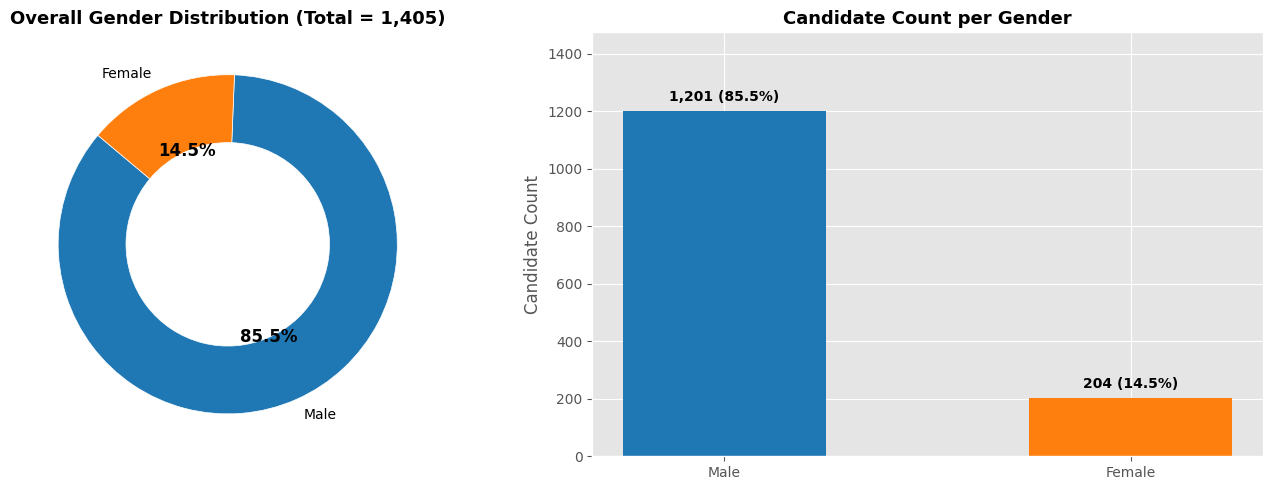

In [8]:
# Dedicated Overall Gender Donut Chart & Bar Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gender_counts = df_en['Gender_EN'].value_counts()
colors = ['#1f77b4', '#ff7f0e']

# Donut Chart with BLACK percentage text color
wedges, texts, autotexts = axes[0].pie(
    gender_counts, 
    labels=gender_counts.index, 
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    wedgeprops=dict(width=0.4, edgecolor='w')
)
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_weight('bold')
    autotext.set_fontsize(12)

axes[0].set_title(f'Overall Gender Distribution (Total = {len(df_en):,})', fontsize=13, fontweight='bold')

# Bar Chart with Value Annotations
bars = axes[1].bar(gender_counts.index, gender_counts.values, color=colors, width=0.5)
axes[1].set_title('Candidate Count per Gender', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Candidate Count')
axes[1].set_ylim(0, len(df_en) * 1.05)

for bar in bars:
    height = bar.get_height()
    pct = (height / len(df_en)) * 100
    axes[1].annotate(f'{height:,} ({pct:.1f}%)',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 5),
                     textcoords="offset points",
                     ha='center', va='bottom', fontweight='bold', color='black')

plt.tight_layout()
plt.show()


### 4.2 Breakdown Visualizations across Categories
Stacked bar charts comparing Male vs Female distribution across Occupations, Assessment Centers, NQ Levels, and Sponsors.


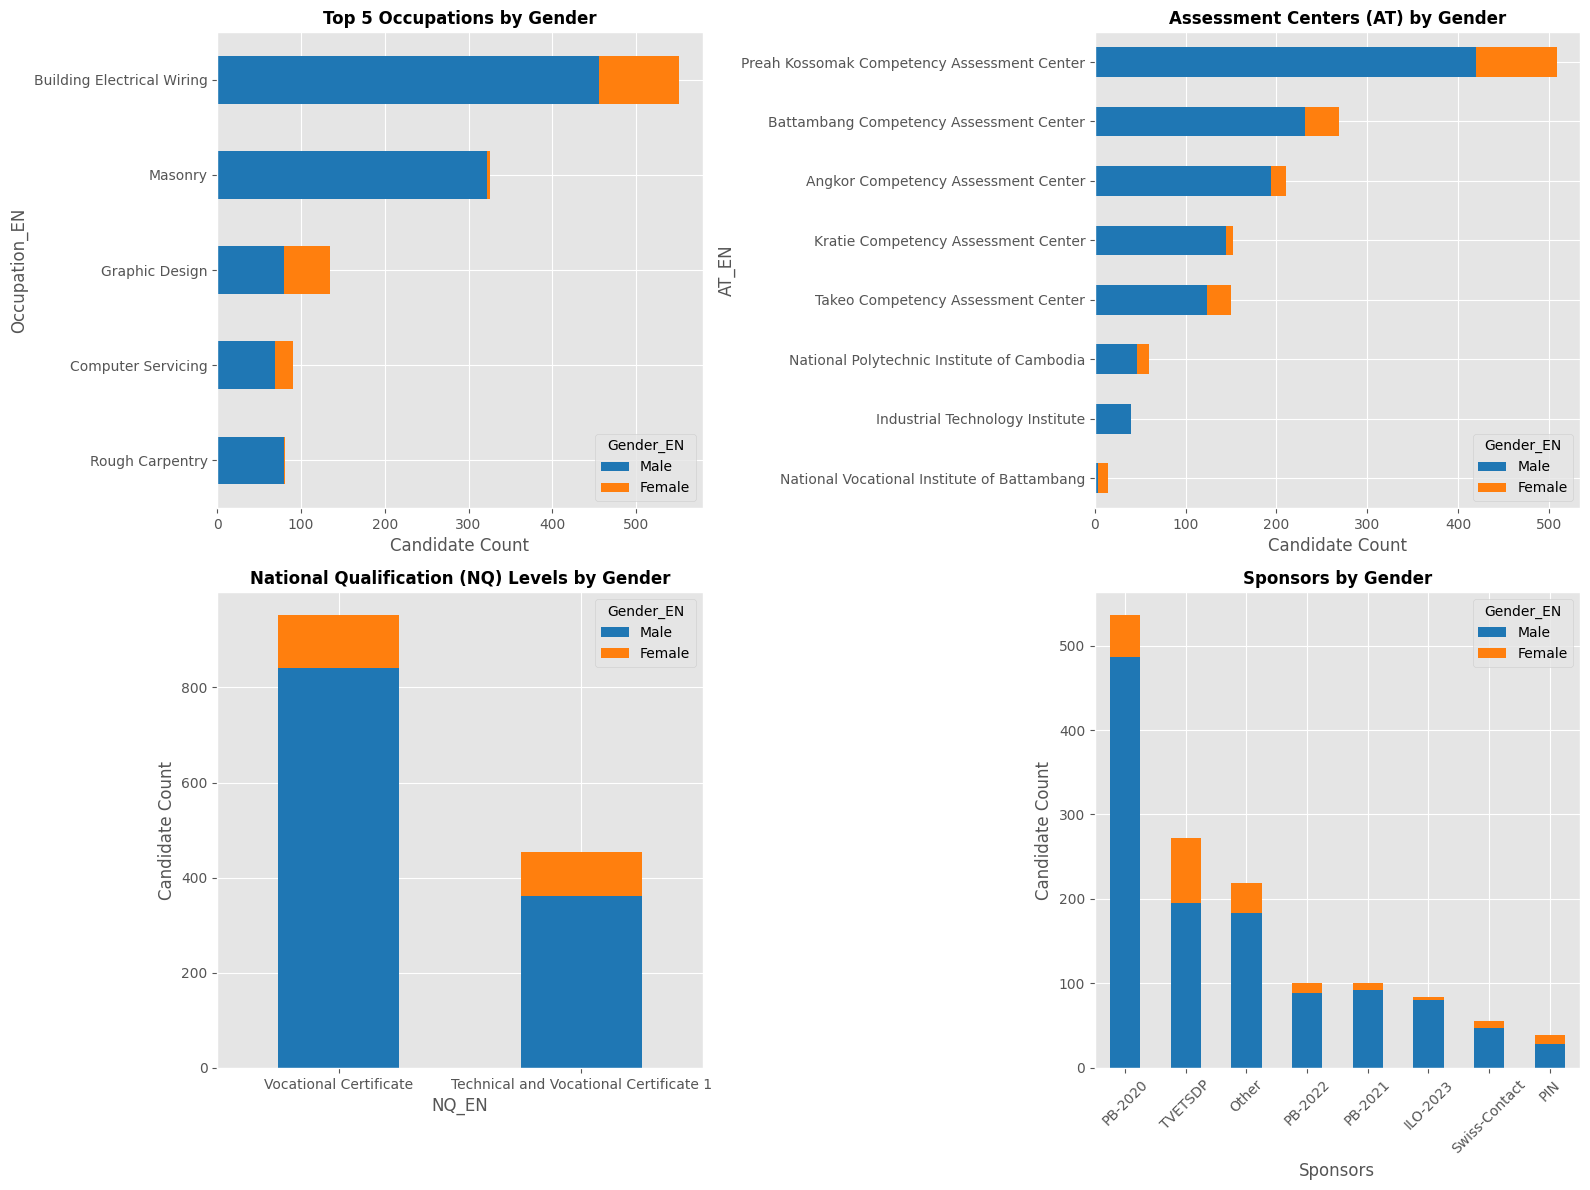

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Top 5 Occupations
top_occ = occ_en_ct.drop('Total').head(5)[['Male', 'Female']]
top_occ.plot(kind='barh', stacked=True, ax=axes[0, 0], color=['#1f77b4', '#ff7f0e'])
axes[0, 0].set_title('Top 5 Occupations by Gender', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Candidate Count')
axes[0, 0].invert_yaxis()

# 2. Assessment Centers
at_data = at_en_ct.drop('Total')[['Male', 'Female']]
at_data.plot(kind='barh', stacked=True, ax=axes[0, 1], color=['#1f77b4', '#ff7f0e'])
axes[0, 1].set_title('Assessment Centers (AT) by Gender', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Candidate Count')
axes[0, 1].invert_yaxis()

# 3. National Qualification (NQ) Levels
nq_data = nq_en_ct.drop('Total')[['Male', 'Female']]
nq_data.plot(kind='bar', stacked=True, ax=axes[1, 0], color=['#1f77b4', '#ff7f0e'])
axes[1, 0].set_title('National Qualification (NQ) Levels by Gender', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Candidate Count')
axes[1, 0].tick_params(axis='x', rotation=0)

# 4. Top Sponsors
sponsor_data = sp_en_ct.drop('Total')[['Male', 'Female']]
sponsor_data.plot(kind='bar', stacked=True, ax=axes[1, 1], color=['#1f77b4', '#ff7f0e'])
axes[1, 1].set_title('Sponsors by Gender', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Candidate Count')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## 5. Key Exploratory Findings & Summary

1. **Overall Gender Distribution:**
   - **Total Candidates:** 1,405 (100.0%)
   - **Male (`Male` / `ប្រុស`):** 1,201 candidates (**85.48%**)
   - **Female (`Female` / `ស្រី`):** 204 candidates (**14.52%**)

2. **Dual DataFrame Structure:**
   - **`df_kh`**: Cleaned dataset using Khmer (`KH`) attributes for internal data analysis and exploration.
   - **`df_en`**: Cleaned dataset dropping KH attributes (`Occupation_KH`, `NQ_KH`, `AT_KH`, `Gender_KH`) for visualization charts and English summary tables.

3. **Key Dimension Breakdown Insights:**
   - **Top Occupation:** Building Electrical Wiring / ការដំឡើងបណ្តាញអគ្គិសនីក្នុងអគារ (552 total: 456 Male, 96 Female)
   - **Top Assessment Center:** Preah Kossomak / មជ្ឈមណ្ឌលវាយតម្លៃសមត្ថភាពព្រះកុសុមៈ (509 total: 420 Male, 89 Female)
   - **Top Qualification Level:** Vocational Certificate / វិញ្ញាបនបត្រវិជ្ជាជីវៈ (952 total: 840 Male, 112 Female)
   - **Top Sponsor:** PB-2020 (536 total: 487 Male, 49 Female)
